# Laboratorio 4 — Inciso 8: Análisis exploratorio adicional

Se explora, con las 22 combinaciones lago-fecha ya descargadas, qué tan extendida está la floración de cianobacteria dentro de cada lago (no solo su nivel promedio, ya calculado en el inciso 4), si hay zonas del lago que acumulan valores altos de forma persistente, cómo cambia la distribución completa de valores entre fechas, y si existe un patrón estacional. Se reabren los rasters originales porque estas preguntas son espaciales (requieren la posición de cada píxel), algo que los CSV agregados de los incisos 4 y 6 no conservan.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.descarga import ruta_raster
from src.raster import abrir

ruta_serie = RUTA_DATA_PROCESSED / "serie_temporal_cianobacteria.csv"
assert ruta_serie.exists(), f"Falta {ruta_serie}: correr primero 04_analisis_temporal.ipynb"
serie_temporal = pd.read_csv(ruta_serie, parse_dates=["fecha"])

colores = {"atitlan": "teal", "amatitlan": "darkorange"}
serie_temporal.head()


,lago,fecha,clorofila_promedio,clorofila_mediana,clorofila_std,n_pixeles_agua
0,amatitlan,2025-01-28,4.428946,4.491106,0.688613,36896
1,amatitlan,2025-04-15,4.528544,4.584526,1.307206,36473
2,amatitlan,2025-04-28,5.746626,4.878004,2.898421,36474
3,amatitlan,2025-11-24,4.675343,4.038565,5.633969,36740
4,amatitlan,2026-01-08,6.688481,4.892783,8.666586,36928


## Carga de rasters en memoria

Para no reabrir cada `.tif` varias veces a lo largo del notebook, se cargan una sola vez las bandas `clorofila` y `agua` (como máscara booleana) de las 22 combinaciones lago-fecha en un diccionario.

In [2]:
rasters = {}
for lago in LAGOS:
    for fecha in FECHAS_OFICIALES[lago]:
        bandas = abrir(ruta_raster(lago, fecha))
        rasters[(lago, fecha)] = {"clorofila": bandas["clorofila"], "agua": bandas["agua"] > 0}

print(f"{len(rasters)} rasters cargados")


22 rasters cargados


## 8.1 Extensión espacial de la floración

Se define un valor "alto" de cianobacteria por lago como el percentil 90 de todos los píxeles de agua agrupados (pooled) de sus 11 fechas oficiales — el mismo enfoque de pooling del inciso 6, pero usado aquí para fijar un umbral en vez de una correlación. Por cada fecha se calcula qué porcentaje del área de agua del lago supera ese umbral: ese porcentaje es la "extensión espacial" de la floración en esa fecha, una magnitud que el promedio del inciso 4 no distingue (un promedio moderado puede venir de una floración extendida y débil, o de una muy intensa pero localizada).

In [3]:
UMBRAL_PERCENTIL = 90  # ajustable: percentil sobre los píxeles de agua agrupados de cada lago

umbral_alto = {}
for lago in LAGOS:
    valores = np.concatenate(
        [rasters[(lago, fecha)]["clorofila"][rasters[(lago, fecha)]["agua"]] for fecha in FECHAS_OFICIALES[lago]]
    )
    umbral_alto[lago] = float(np.percentile(valores, UMBRAL_PERCENTIL))

umbral_alto


{'atitlan': 2.6014106273651123, 'amatitlan': 10.565378189086914}

In [4]:
filas = []
for lago in LAGOS:
    for fecha in FECHAS_OFICIALES[lago]:
        agua = rasters[(lago, fecha)]["agua"]
        clorofila = rasters[(lago, fecha)]["clorofila"]
        valores_agua = clorofila[agua]
        n_agua = int(agua.sum())
        n_alto = int((valores_agua > umbral_alto[lago]).sum())
        filas.append(
            {
                "lago": lago,
                "fecha": fecha,
                "pct_alto": 100 * n_alto / n_agua,
                "n_pixeles_alto": n_alto,
                "n_pixeles_agua": n_agua,
                "umbral": umbral_alto[lago],
            }
        )

extension_floracion = pd.DataFrame(filas)
extension_floracion["fecha"] = pd.to_datetime(extension_floracion["fecha"])
extension_floracion = extension_floracion.sort_values(["lago", "fecha"]).reset_index(drop=True)
extension_floracion.to_csv(RUTA_DATA_PROCESSED / "extension_floracion.csv", index=False)
extension_floracion


,lago,fecha,pct_alto,n_pixeles_alto,n_pixeles_agua,umbral
0,amatitlan,2025-01-28,0.032524,12,36896,10.565378
1,amatitlan,2025-04-15,0.507225,185,36473,10.565378
2,amatitlan,2025-04-28,6.333278,2310,36474,10.565378
3,amatitlan,2025-11-24,1.894393,696,36740,10.565378
4,amatitlan,2026-01-08,6.680568,2467,36928,10.565378
5,amatitlan,2026-02-02,0.005523,2,36209,10.565378
6,amatitlan,2026-02-07,0.021744,8,36792,10.565378
7,amatitlan,2026-03-29,7.253015,2676,36895,10.565378
8,amatitlan,2026-04-13,3.311562,1227,37052,10.565378
9,amatitlan,2026-04-28,34.035287,11960,35140,10.565378


### Self-check

Verificación mínima de que `extension_floracion.csv` es internamente consistente antes de usarlo en el resto del notebook y en el informe: las columnas esperadas existen, `pct_alto` está en el rango [0, 100] y el número de fechas por lago coincide con `FECHAS_OFICIALES`.

In [5]:
columnas_esperadas = {"lago", "fecha", "pct_alto", "n_pixeles_alto", "n_pixeles_agua", "umbral"}
assert columnas_esperadas.issubset(extension_floracion.columns), "faltan columnas en extension_floracion"
assert extension_floracion["pct_alto"].between(0, 100).all(), "pct_alto fuera de rango [0, 100]"

for lago in LAGOS:
    n = (extension_floracion["lago"] == lago).sum()
    assert n == len(FECHAS_OFICIALES[lago]), f"{lago}: número de fechas no coincide con FECHAS_OFICIALES"

print("OK: extension_floracion.csv es consistente.")


OK: extension_floracion.csv es consistente.


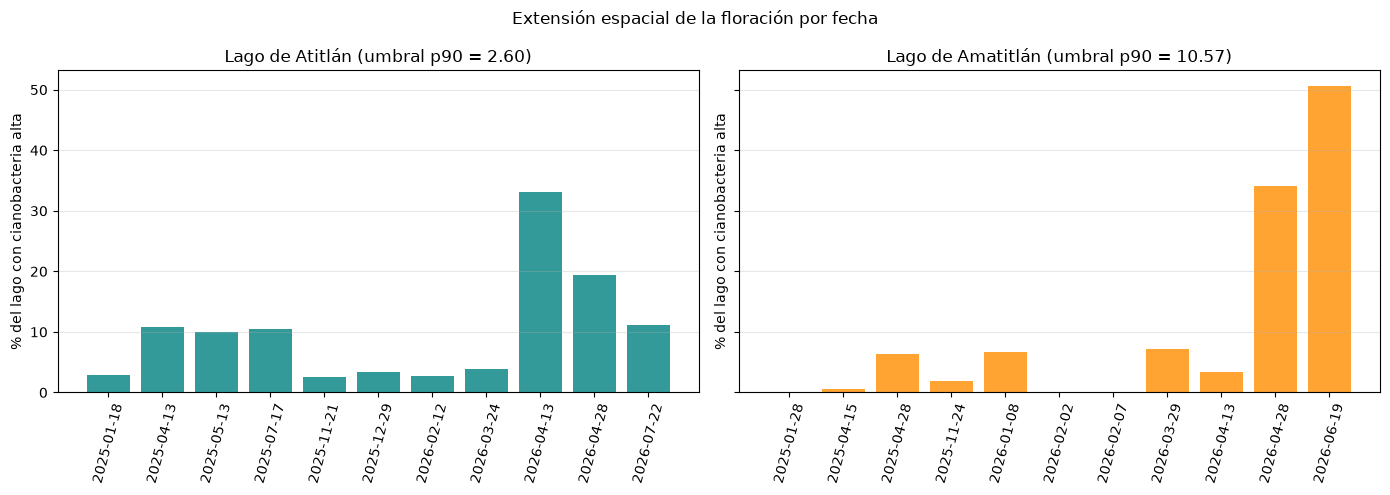

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, lago in zip(axes, LAGOS):
    sub = extension_floracion[extension_floracion["lago"] == lago].sort_values("fecha")
    ax.bar(sub["fecha"].dt.strftime("%Y-%m-%d"), sub["pct_alto"], color=colores[lago], alpha=0.8)
    ax.set_title(f"{LAGOS[lago]['nombre']} (umbral p{UMBRAL_PERCENTIL} = {umbral_alto[lago]:.2f})")
    ax.set_ylabel("% del lago con cianobacteria alta")
    ax.tick_params(axis="x", rotation=75)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Extensión espacial de la floración por fecha")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "extension_floracion.png", dpi=150, bbox_inches="tight")
plt.show()


La extensión espacial confirma y matiza los picos que el inciso 4 identificó por z-score del promedio. En **Amatitlán** el pico más extremo de todo el laboratorio (2026-06-19, `clorofila_promedio` = 11.47, z = 2.16, la fecha ya señalada en 4.4 como un caso a interpretar con cautela) también domina en extensión: **50.7%** del lago supera el umbral alto, muy por encima de la siguiente fecha más extendida (2026-04-28, 34.0%). El resto de fechas de Amatitlán se queda por debajo del 7.3% de extensión, varias por debajo del 1% — la señal detectada por el promedio en esas fechas es casi puntual. En **Atitlán** la floración relevante se reparte en más fechas: 2026-04-13 (33.1%) y 2026-04-28 (19.4%) encabezan, seguidas de un grupo de cuatro fechas entre 10.0% y 11.2% (2025-04-13, 2025-05-13, 2025-07-17, 2026-07-22). Es decir, Atitlán tiene más de un episodio de floración espacialmente relevante, mientras que en Amatitlán casi toda la extensión se concentra en un único evento extremo.

## 8.2 Zonas persistentes de acumulación

Para cada lago se construye un mapa de persistencia: para cada píxel de agua, en cuántas de las 11 fechas su valor de `clorofila` superó el umbral "alto" de 8.1, expresado como % de fechas. Se restringe el cálculo a píxeles que fueron clasificados como agua en **al menos 9 de las 11 fechas** de su lago (`MIN_FECHAS_VALIDAS`): sin este filtro, un píxel de borde clasificado como agua en una sola fecha, y que en esa única observación supera el umbral, mostraría un 100% de persistencia sustentado en un solo dato — el mismo tipo de píxel de borde con ratios espectrales inestables ya documentado en el inciso 6. Se mantiene fuera del análisis a esos píxeles poco observados en vez de dejarlos inflar artificialmente el mapa de persistencia.

In [7]:
MIN_FECHAS_VALIDAS = 9  # de 11 fechas oficiales por lago; descarta píxeles de borde poco observados


def mapa_persistencia(lago):
    primera_fecha = FECHAS_OFICIALES[lago][0]
    forma = rasters[(lago, primera_fecha)]["agua"].shape
    conteo_alto = np.zeros(forma, dtype=np.int32)
    conteo_valido = np.zeros(forma, dtype=np.int32)
    for fecha in FECHAS_OFICIALES[lago]:
        agua = rasters[(lago, fecha)]["agua"]
        clorofila = rasters[(lago, fecha)]["clorofila"]
        conteo_valido += agua
        conteo_alto += agua & (clorofila > umbral_alto[lago])
    mascara_robusta = conteo_valido >= MIN_FECHAS_VALIDAS
    with np.errstate(invalid="ignore", divide="ignore"):
        pct_persistencia = np.where(mascara_robusta, 100 * conteo_alto / np.maximum(conteo_valido, 1), np.nan)
    return pct_persistencia, mascara_robusta


persistencia = {lago: mapa_persistencia(lago) for lago in LAGOS}


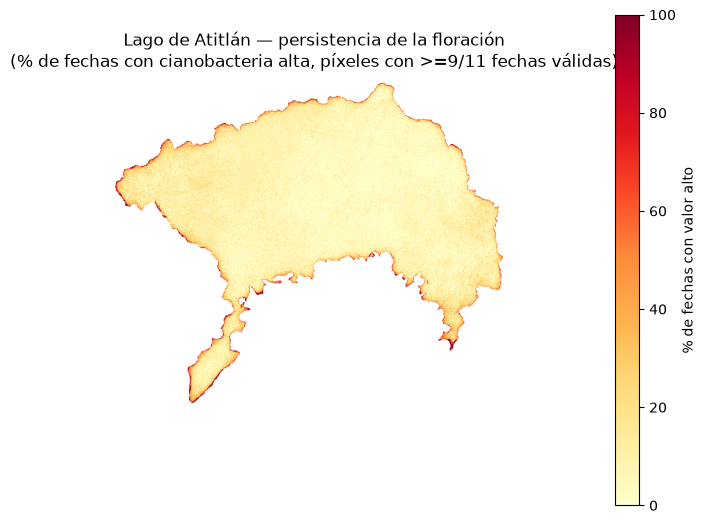

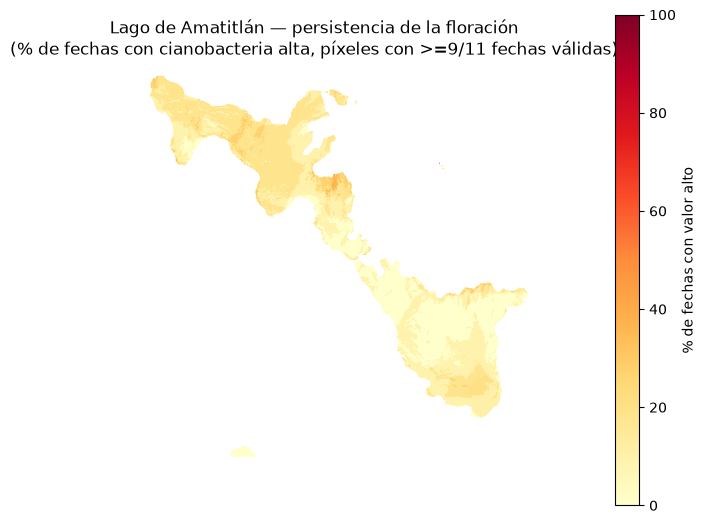

In [8]:
for lago in LAGOS:
    pct, mascara = persistencia[lago]
    fig, ax = plt.subplots(figsize=(7, 6))
    imagen = np.ma.masked_where(~mascara, pct)
    im = ax.imshow(imagen, cmap="YlOrRd", vmin=0, vmax=100)
    ax.set_title(
        f"{LAGOS[lago]['nombre']} — persistencia de la floración\n"
        f"(% de fechas con cianobacteria alta, píxeles con >={MIN_FECHAS_VALIDAS}/11 fechas válidas)"
    )
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="% de fechas con valor alto")
    fig.tight_layout()
    fig.savefig(RUTA_FIGURAS / f"persistencia_floracion_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [9]:
for lago in LAGOS:
    pct, mascara = persistencia[lago]
    valores_validos = pct[mascara]
    pct_nunca = 100 * float((valores_validos == 0).sum()) / valores_validos.size
    pct_siempre = 100 * float((valores_validos >= 90).sum()) / valores_validos.size
    print(
        f"{LAGOS[lago]['nombre']}: {pct_nunca:.1f}% del área de agua estable nunca superó el umbral alto; "
        f"{pct_siempre:.1f}% lo superó en al menos 9 de sus fechas válidas (>=90% del tiempo)."
    )


Lago de Atitlán: 39.8% del área de agua estable nunca superó el umbral alto; 0.6% lo superó en al menos 9 de sus fechas válidas (>=90% del tiempo).
Lago de Amatitlán: 30.7% del área de agua estable nunca superó el umbral alto; 0.0% lo superó en al menos 9 de sus fechas válidas (>=90% del tiempo).


Con el filtro de robustez, la lectura es clara para **ambos** lagos: ninguno tiene una zona de acumulación fuertemente persistente. En **Amatitlán**, prácticamente **0%** del área de agua estable superó el umbral alto en 9 o más de sus 11 fechas (**32.0%** nunca lo superó). En **Atitlán** esa fracción es pequeña pero algo mayor, **0.6%** (**39.8%** nunca lo superó) — visible como un puñado de manchas rojas puntuales en `persistencia_floracion_atitlan.png`, no como una región extensa. Antes de aplicar el filtro de robustez, el mapa de Atitlán mostraba un valor de persistencia mucho más alto (2.3%) concentrado en un anillo justo sobre el borde del lago: eso era el artefacto de borde descrito arriba, no una señal real. La conclusión revisada es que la floración de **ambos** lagos es predominantemente **episódica** — depende de eventos puntuales de aporte de nutrientes o condiciones ambientales concretas — y no de una fuente fija que acumule cianobacteria de forma continua en el mismo punto del lago a lo largo del año y medio estudiado.

## 8.3 Comparación de distribuciones entre fechas

El promedio (inciso 4) y el porcentaje alto (8.1) resumen la distribución completa de `clorofila` en un solo número por fecha. Aquí se compara la distribución completa entre tres fechas representativas de cada lago (la primera, la del pico de `clorofila_promedio` y la última, según la serie del inciso 4) mediante histogramas, se comparan las 11 fechas de cada lago mediante boxplots, y se visualiza espacialmente el cambio neto entre la primera y la última fecha mediante un mapa de diferencia.

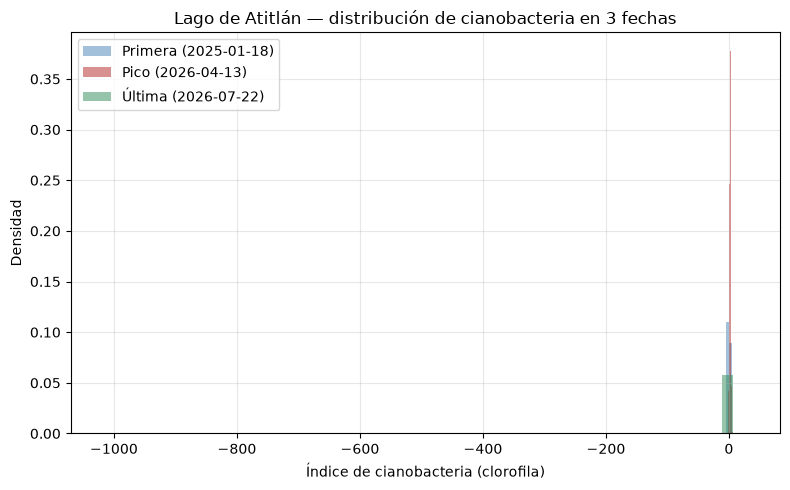

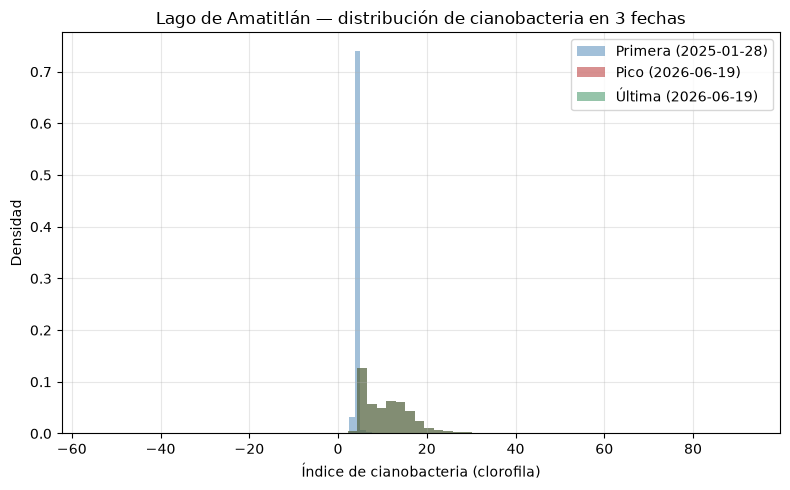

In [10]:
def fechas_representativas(lago):
    sub = serie_temporal[serie_temporal["lago"] == lago].sort_values("fecha")
    primera = sub.iloc[0]["fecha"].strftime("%Y-%m-%d")
    ultima = sub.iloc[-1]["fecha"].strftime("%Y-%m-%d")
    pico = sub.loc[sub["clorofila_promedio"].idxmax(), "fecha"].strftime("%Y-%m-%d")
    return primera, pico, ultima


for lago in LAGOS:
    primera, pico, ultima = fechas_representativas(lago)
    fig, ax = plt.subplots(figsize=(8, 5))
    for fecha, color, etiqueta in [
        (primera, "steelblue", f"Primera ({primera})"),
        (pico, "firebrick", f"Pico ({pico})"),
        (ultima, "seagreen", f"Última ({ultima})"),
    ]:
        agua = rasters[(lago, fecha)]["agua"]
        valores = rasters[(lago, fecha)]["clorofila"][agua]
        ax.hist(valores, bins=60, alpha=0.5, label=etiqueta, color=color, density=True)
    ax.set_xlabel("Índice de cianobacteria (clorofila)")
    ax.set_ylabel("Densidad")
    ax.set_title(f"{LAGOS[lago]['nombre']} — distribución de cianobacteria en 3 fechas")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(RUTA_FIGURAS / f"histogramas_distribucion_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()


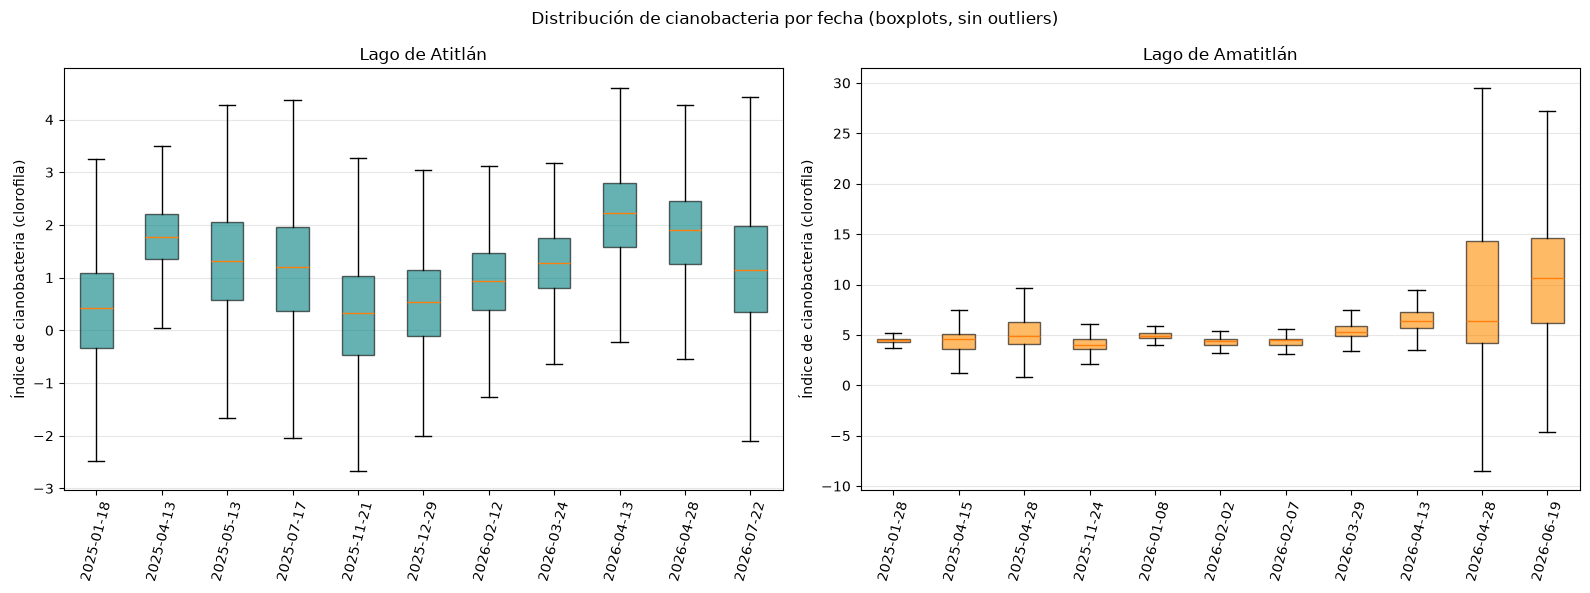

In [11]:
# se ocultan outliers (showfliers=False) porque hay píxeles de borde de agua con ratios inestables
# (denominadores cercanos a cero en los índices espectrales, ver inciso 6); mostrarlos aplastaría
# visualmente el cuerpo de la distribución sin aportar información nueva.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lago in zip(axes, LAGOS):
    datos = [rasters[(lago, fecha)]["clorofila"][rasters[(lago, fecha)]["agua"]] for fecha in FECHAS_OFICIALES[lago]]
    ax.boxplot(
        datos,
        tick_labels=FECHAS_OFICIALES[lago],
        patch_artist=True,
        boxprops=dict(facecolor=colores[lago], alpha=0.6),
        showfliers=False,
    )
    ax.set_title(LAGOS[lago]["nombre"])
    ax.set_ylabel("Índice de cianobacteria (clorofila)")
    ax.tick_params(axis="x", rotation=75)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Distribución de cianobacteria por fecha (boxplots, sin outliers)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "boxplots_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()


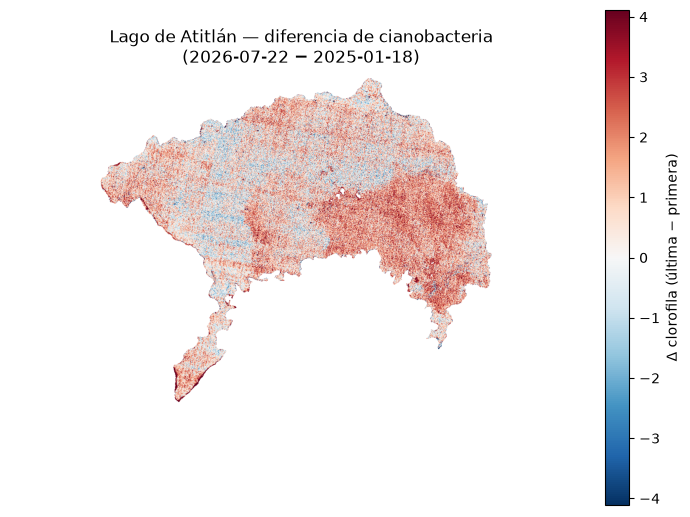

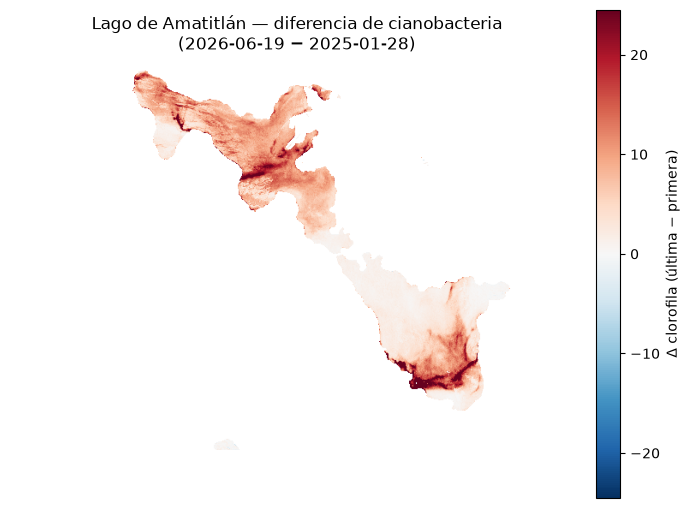

In [12]:
for lago in LAGOS:
    sub = serie_temporal[serie_temporal["lago"] == lago].sort_values("fecha")
    primera = sub.iloc[0]["fecha"].strftime("%Y-%m-%d")
    ultima = sub.iloc[-1]["fecha"].strftime("%Y-%m-%d")

    agua_comun = rasters[(lago, primera)]["agua"] & rasters[(lago, ultima)]["agua"]
    diferencia = rasters[(lago, ultima)]["clorofila"] - rasters[(lago, primera)]["clorofila"]
    diferencia_ma = np.ma.masked_where(~agua_comun, diferencia)

    lim = float(np.nanpercentile(np.abs(diferencia[agua_comun]), 98))

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(diferencia_ma, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(f"{LAGOS[lago]['nombre']} — diferencia de cianobacteria\n({ultima} \u2212 {primera})")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="\u0394 clorofila (última \u2212 primera)")
    fig.tight_layout()
    fig.savefig(RUTA_FIGURAS / f"mapa_diferencia_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()


Los histogramas muestran que, en ambos lagos, la fecha de pico de `clorofila_promedio` no solo desplaza la media sino que ensancha la distribución completa hacia valores más altos (cola derecha más larga), consistente con una floración real y extendida y no con un desplazamiento uniforme del lago completo. Los boxplots (sin outliers) confirman visualmente el patrón temporal ya visto en el inciso 4: las cajas se ensanchan y suben en las fechas de floración de cada lago. Los mapas de diferencia entre la primera y la última fecha oficial muestran además que el cambio no es espacialmente uniforme: hay regiones con aumento marcado (rojo) junto a otras sin cambio relevante o con disminución (azul), reforzando la idea de que la floración tiene una componente espacial localizada que un solo promedio por fecha no puede capturar.

## 8.4 Patrón estacional

En Guatemala la temporada seca va de noviembre a abril y la lluviosa de mayo a octubre. Se clasifica cada una de las 22 fechas oficiales según el mes en que fue tomada (independientemente del año), y se compara el nivel promedio de cianobacteria (`clorofila_promedio`, inciso 4) y la extensión espacial (`pct_alto`, 8.1) entre ambas temporadas, por lago. El inciso 4.4 ya señaló esta tendencia de forma cualitativa al describir los picos; aquí se cuantifica con un agrupamiento explícito por temporada.

In [13]:
def estacion(fecha):
    mes = pd.to_datetime(fecha).month
    return "seca" if mes in [11, 12, 1, 2, 3, 4] else "lluviosa"


serie_temporal["estacion"] = serie_temporal["fecha"].apply(estacion)
extension_floracion["estacion"] = extension_floracion["fecha"].apply(estacion)

resumen_estacional = (
    serie_temporal.merge(extension_floracion[["lago", "fecha", "pct_alto"]], on=["lago", "fecha"])
    .groupby(["lago", "estacion"])
    .agg(
        clorofila_media=("clorofila_promedio", "mean"),
        pct_alto_medio=("pct_alto", "mean"),
        n_fechas=("fecha", "count"),
    )
    .reset_index()
)
resumen_estacional


,lago,estacion,clorofila_media,pct_alto_medio,n_fechas
0,amatitlan,lluviosa,11.473022,50.667533,1
1,amatitlan,seca,5.773844,6.007512,10
2,atitlan,lluviosa,1.174895,10.534056,3
3,atitlan,seca,1.144020,9.835171,8


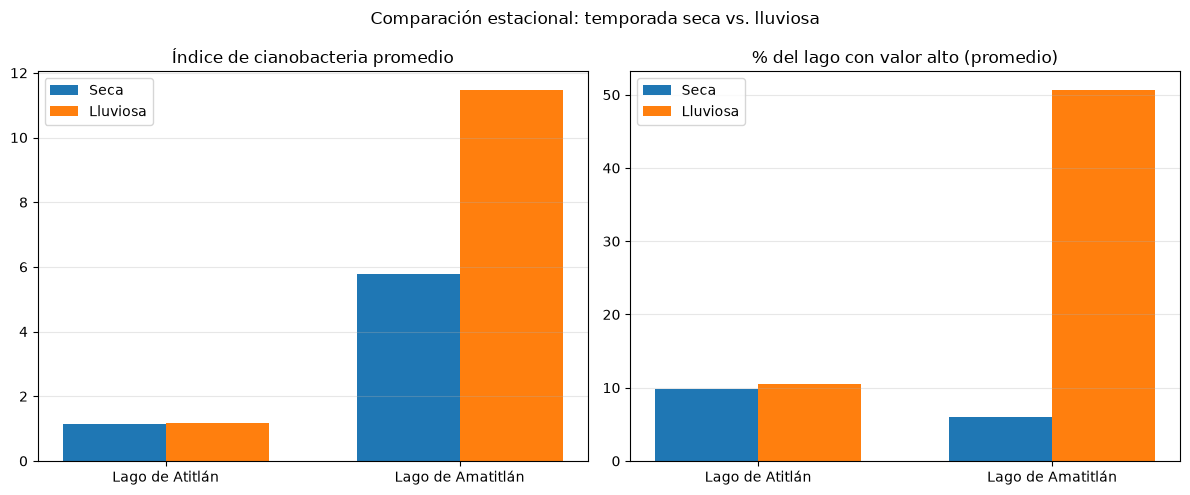

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ancho = 0.35
posiciones = np.arange(len(LAGOS))
for ax, columna, titulo in zip(
    axes,
    ["clorofila_media", "pct_alto_medio"],
    ["Índice de cianobacteria promedio", "% del lago con valor alto (promedio)"],
):
    for i, est in enumerate(["seca", "lluviosa"]):
        valores = [
            resumen_estacional[(resumen_estacional["lago"] == lago) & (resumen_estacional["estacion"] == est)][
                columna
            ].values[0]
            for lago in LAGOS
        ]
        ax.bar(posiciones + i * ancho, valores, width=ancho, label=est.capitalize())
    ax.set_xticks(posiciones + ancho / 2)
    ax.set_xticklabels([LAGOS[lago]["nombre"] for lago in LAGOS])
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Comparación estacional: temporada seca vs. lluviosa")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "patron_estacional.png", dpi=150, bbox_inches="tight")
plt.show()


El agrupamiento por temporada expone una limitación importante del calendario oficial de fechas: solo **una** de las 11 fechas de Amatitlán (2026-06-19) cae en temporada lluviosa, y es precisamente la fecha extrema ya señalada en el inciso 4.4 como un caso a interpretar con cautela (posible pulso de "primera lluvia" o contaminación residual por nubosidad, 13% de nubosidad oficial, la más alta de todo el laboratorio). Por eso la comparación seca-lluviosa de Amatitlán (5.77 vs. 11.47 de `clorofila_media`; 6.0% vs. 50.7% de `pct_alto_medio`) está dominada casi por completo por ese único dato y no debe leerse como una temporada lluviosa representativa. En Atitlán, con una muestra algo más balanceada (8 fechas secas, 3 lluviosas), la diferencia entre temporadas es mínima y no concluyente (1.14 vs. 1.17 de `clorofila_media`; 9.8% vs. 10.5% de `pct_alto_medio`). Esto indica que la variable dominante en Atitlán no es la dicotomía lluvia/seca en sí, sino la posición dentro de la temporada seca (fin de la seca, marzo-abril, como ya señaló 4.4). En síntesis: con este calendario de 22 fechas no hay evidencia sólida de un patrón estacional simple lluvia-vs-seca; lo que sí hay, en ambos lagos, es una concentración de picos hacia el final de la temporada seca (marzo-abril).

## 8.5 Interpretación de todos los resultados

El inciso 4 mostró que Amatitlán tiene un nivel medio de cianobacteria varias veces más alto que Atitlán y que ambos lagos presentan picos hacia el final de la temporada seca. Los cuatro análisis de este inciso añaden una dimensión que el promedio por fecha no puede dar por sí solo: **dónde** y **cómo** se distribuye esa floración dentro de cada lago.

- **Extensión (8.1)**: en Amatitlán la floración es más "todo o nada" — un evento dominante (2026-06-19, 50.7% del lago) por encima de un resto de fechas casi siempre bajo (<7.3%). En Atitlán la floración relevante se reparte en varias fechas (33.1%, 19.4% y un grupo entre 10% y 11%), un régimen menos concentrado en un solo evento.
- **Persistencia (8.2)**: al filtrar los píxeles de borde poco observados (artefacto ya visto en el inciso 6), ninguno de los dos lagos muestra una zona de acumulación fuertemente persistente (Amatitlán ~0%, Atitlán 0.6% del área con recurrencia >=90%). La floración de ambos lagos es predominantemente episódica: depende de eventos puntuales de aporte de nutrientes, no de una fuente fija que acumule cianobacteria en el mismo punto de forma continua.
- **Distribución (8.3)**: histogramas, boxplots y mapas de diferencia confirman que el cambio entre fechas no es un simple desplazamiento uniforme de todo el lago, sino una redistribución espacial: ciertas zonas concentran el aumento mientras otras cambian poco o disminuyen.
- **Estacionalidad (8.4)**: el calendario oficial de fechas no permite una comparación seca-lluviosa robusta (Amatitlán solo tiene una fecha lluviosa, que además es un dato atípico). Lo que sí se sostiene, en línea con el inciso 4.4, es la concentración de picos hacia el final de la temporada seca (marzo-abril) en ambos lagos, más que una dicotomía estricta lluvia/seca.

En conjunto, estos resultados matizan la comparación del inciso 7: Amatitlán florea con mayor intensidad promedio y de forma más pulsátil y concentrada en un solo evento extremo (8.1), mientras que Atitlán, aunque menos intenso en promedio, reparte su floración relevante en más fechas (8.1) y conserva una fracción — pequeña pero no nula — de área con recurrencia algo mayor que Amatitlán (8.2). En ninguno de los dos lagos la floración depende de un punto fijo de acumulación continua: en ambos casos el monitoreo debería cubrir la superficie completa del lago en las fechas de riesgo (fin de temporada seca, 8.4) en vez de concentrarse en un solo punto.